# LAB | Introducción al Machine Learning
**Dataset:** Spaceship Titanic  
**Modelo:** K-Nearest Neighbors (KNN)  
**Tipo:** Clasificación

## Tabla de Contenidos
1. [Cargar los datos](#1)
2. [Explorar los datos](#2)
3. [Gestionar valores nulos](#3)
4. [Seleccionar features y target](#4)
5. [Train Test Split](#5)
6. [Selección y entrenamiento del modelo](#6)
7. [Evaluación del modelo](#7)

## 1. Cargar los datos <a id='1'></a>

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el dataset directamente desde la URL
spaceship = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv")
spaceship.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 2. Explorar los datos <a id='2'></a>

In [3]:
# Comprobar el shape del dataset
# Nos indica cuántas filas (pasajeros) y columnas (features) tenemos
spaceship.shape

(8693, 14)

In [4]:
# Comprobar los tipos de datos
# Es importante porque KNN requiere que todas las features de entrada sean numéricas
spaceship.dtypes

PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

## 3. Gestionar valores nulos <a id='3'></a>

In [5]:
# Comprobar los valores nulos por columna
spaceship.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [6]:
# Eliminar las filas que contengan algún valor nulo
# Usamos esta estrategia porque la cantidad de nulos es baja (~2-3% por columna)
# por lo que no perdemos una cantidad significativa de datos
spaceship = spaceship.dropna()

# Confirmamos que ya no hay valores nulos
print("Valores nulos tras dropna:", spaceship.isnull().sum().sum())
print("Nuevo shape:", spaceship.shape)

Valores nulos tras dropna: 0
Nuevo shape: (6606, 14)


## 4. Seleccionar features y target <a id='4'></a>

In [7]:
# KNN es un algoritmo basado en distancias, por lo que necesita que todas las features sean numéricas
# Seleccionamos solo las columnas numéricas como features
# 'Transported' queda excluida aquí porque es nuestra variable target
numerical_cols = spaceship.select_dtypes(include='number').columns.tolist()
print("Columnas numéricas:", numerical_cols)

X = spaceship[numerical_cols]
X.head()

Columnas numéricas: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,39.0,0.0,0.0,0.0,0.0,0.0
1,24.0,109.0,9.0,25.0,549.0,44.0
2,58.0,43.0,3576.0,0.0,6715.0,49.0
3,33.0,0.0,1283.0,371.0,3329.0,193.0
4,16.0,303.0,70.0,151.0,565.0,2.0


In [8]:
# Definir la variable target
# 'Transported' es booleana (True/False) -> esto es un problema de CLASIFICACIÓN
# Por eso usamos KNeighborsClassifier y no KNeighborsRegressor
y = spaceship['Transported']
y.value_counts()

Transported
True     3327
False    3279
Name: count, dtype: int64

## 5. Train Test Split <a id='5'></a>

In [9]:
# Dividir los datos en conjunto de entrenamiento (80%) y de prueba (20%)
# - Conjunto de entrenamiento: el modelo aprende con estos datos
# - Conjunto de prueba: lo usamos para evaluar cómo generaliza el modelo a datos nuevos
# random_state=42 garantiza que los resultados sean reproducibles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento: (5284, 6)
Tamaño del conjunto de prueba: (1322, 6)


## 6. Selección y entrenamiento del modelo <a id='6'></a>

Usamos **KNeighborsClassifier** porque nuestra variable target (`Transported`) es booleana/categórica.  
Si el target fuera un valor numérico continuo, usaríamos `KNeighborsRegressor` en su lugar.

In [10]:
# Inicializar KNN sin configurar ningún hiperparámetro
# Por defecto, sklearn utiliza n_neighbors=5
knn = KNeighborsClassifier()
knn

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [11]:
# Entrenar el modelo con los datos de entrenamiento
# El modelo 'memoriza' los puntos del conjunto de entrenamiento y sus etiquetas
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## 7. Evaluación del modelo <a id='7'></a>

In [12]:
# Realizar predicciones sobre el conjunto de prueba
y_pred = knn.predict(X_test)

# Accuracy: porcentaje de predicciones correctas
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7716


In [13]:
# Reporte de clasificación: precisión, recall y F1-score por clase
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.79      0.74      0.76       653
        True       0.76      0.80      0.78       669

    accuracy                           0.77      1322
   macro avg       0.77      0.77      0.77      1322
weighted avg       0.77      0.77      0.77      1322



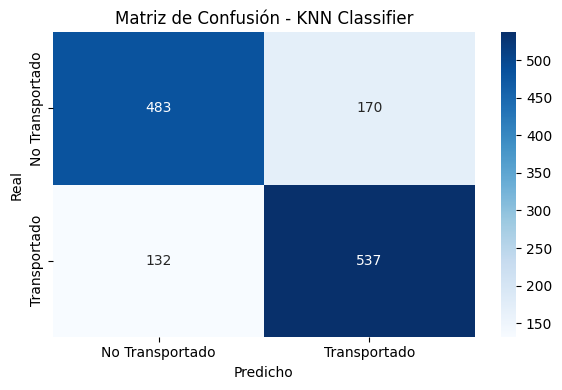

In [14]:
# Matriz de confusión: visualiza las predicciones correctas e incorrectas
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Transportado', 'Transportado'],
            yticklabels=['No Transportado', 'Transportado'])
plt.title('Matriz de Confusión - KNN Classifier')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()